EXPERIMENT 8
SARSA AND Q-LEARNING COMPARATIVE ANALYSIS

10 SAMPLE DATASET RECORDS


,State,Action,Next_State,Reward
0,5,1,0,5.38
1,6,0,3,7.05
2,4,0,5,0.97
3,8,0,3,6.24
4,0,0,3,5.83
5,7,1,4,5.87
6,7,1,3,4.90
7,4,0,1,3.29
8,4,1,4,0.88
9,3,0,3,6.57


Total Records: 500


,min,max,mean,std
State,0.0,9.0,4.494,2.552
Action,0.0,1.0,0.486,0.500
Next_State,0.0,9.0,4.600,2.767
Reward,-5.0,10.0,2.527,4.051



DOWNLOAD DATASET:


...

,State,Action 0 - Forward,Action 1 - Backward
0,0,-1.391,-2.401
1,1,-0.434,-2.370
2,2,0.629,-1.666
3,3,1.810,-0.612
4,4,3.122,0.323
5,5,4.580,1.514
6,6,6.200,2.900
7,7,8.000,4.143
8,8,10.000,5.875
9,9,0.000,0.000



SARSA VS Q-LEARNING COMPARISON


,Algorithm,Total Reward,Average Reward,Maximum Q Value,Best Action State 0
0,SARSA,200,0.400,10.0,0
1,Q-Learning,249,0.498,10.0,0



SUMMARY RESULTS


,Metric,Result
0,Dataset Records,500
1,Episodes,500
2,States,10
3,Actions,2
4,Learning Rate,0.1
5,Discount Factor,0.9
6,Epsilon,0.1
7,SARSA Average Reward,0.4
8,Q-Learning Average Reward,0.498
9,Best Algorithm,Q-Learning


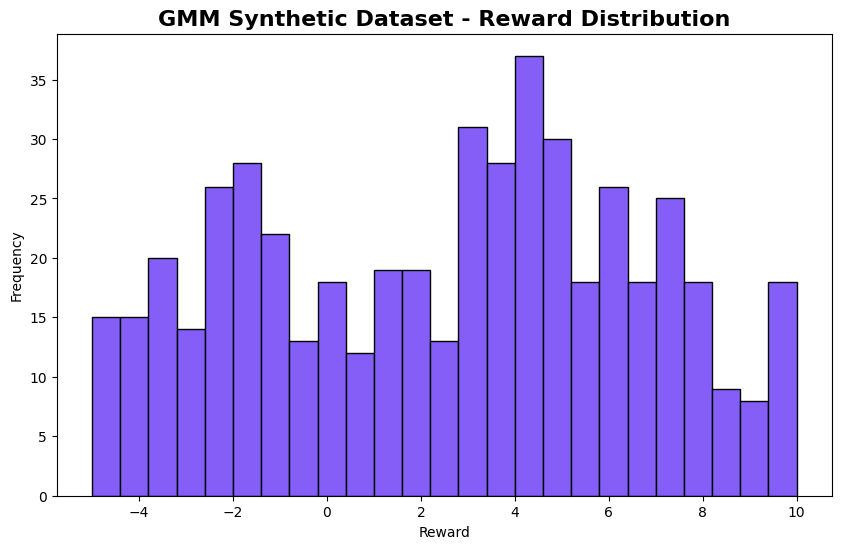

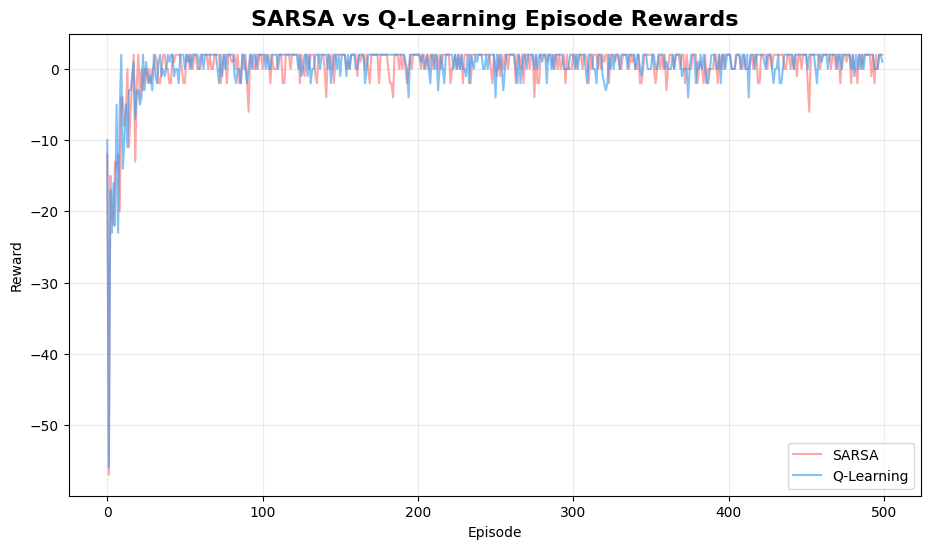

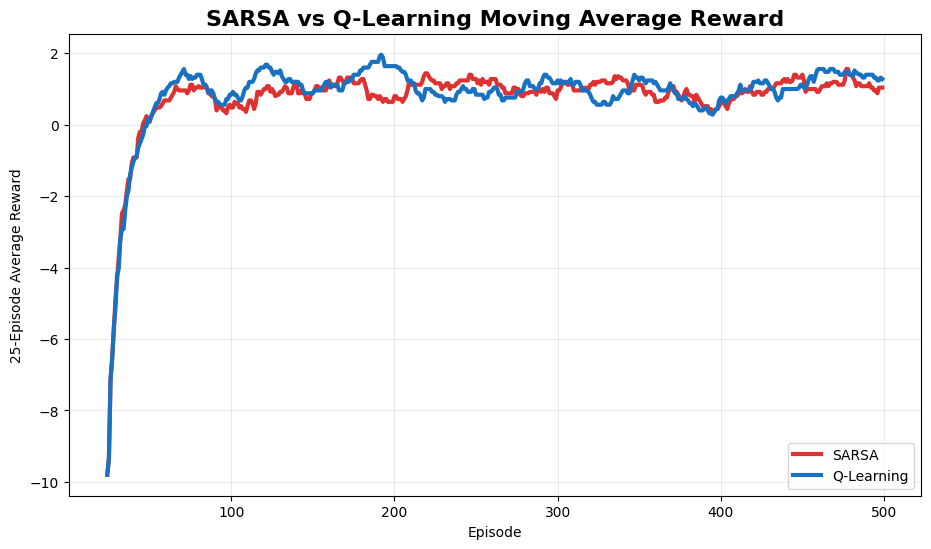

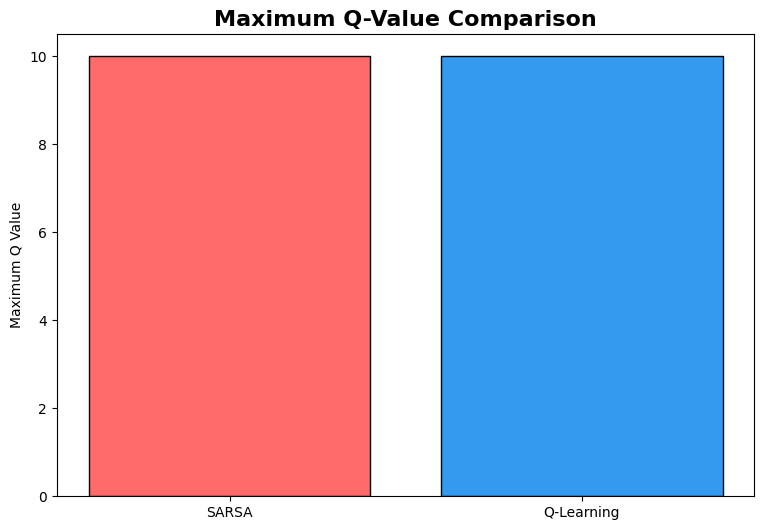

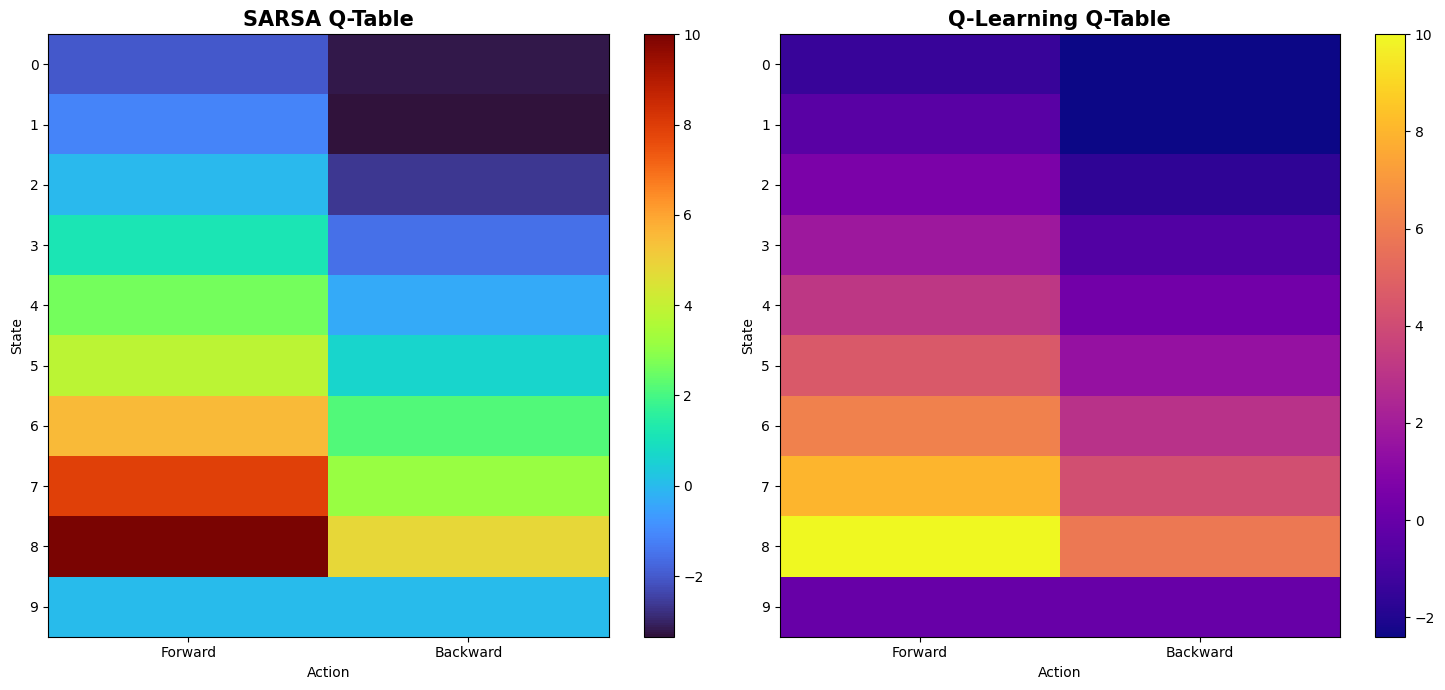


FINAL RESULT

SARSA Average Reward      : 0.400
Q-Learning Average Reward : 0.498

Better performing algorithm based on
average reward: Q-Learning

500 GMM records generated.
10 sample records displayed.
Complete CSV dataset available for download.

Experiment 8 completed successfully.


In [ ]:
# ==============================================================
# EXPERIMENT 8
# IMPLEMENTATION AND COMPARATIVE ANALYSIS
# OF SARSA AND Q-LEARNING
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from IPython.display import display, FileLink
from google.colab import files

np.random.seed(42)

print("=" * 80)
print("EXPERIMENT 8")
print("SARSA AND Q-LEARNING COMPARATIVE ANALYSIS")
print("=" * 80)

# ==============================================================
# 1. GMM DATASET
# ==============================================================

N = 500

base = np.column_stack([
    np.random.randint(0, 10, N),
    np.random.randint(0, 2, N),
    np.random.randint(0, 10, N),
    np.random.uniform(-5, 10, N)
])

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(base)

generated = gmm.sample(N)[0]

dataset = pd.DataFrame(
    generated,
    columns=[
        "State",
        "Action",
        "Next_State",
        "Reward"
    ]
)

dataset["State"] = dataset["State"].clip(0, 9).round().astype(int)
dataset["Action"] = dataset["Action"].clip(0, 1).round().astype(int)
dataset["Next_State"] = dataset["Next_State"].clip(0, 9).round().astype(int)
dataset["Reward"] = dataset["Reward"].clip(-5, 10).round(2)

# ==============================================================
# 2. 10 SAMPLE RECORDS
# ==============================================================

print("\n10 SAMPLE DATASET RECORDS")

display(dataset.head(10))

print("Total Records:", len(dataset))

# ==============================================================
# 3. DATASET SUMMARY
# ==============================================================

display(
    dataset.describe().T[
        ["min", "max", "mean", "std"]
    ].round(3)
)

# ==============================================================
# 4. DOWNLOAD DATASET
# ==============================================================

filename = "Experiment_8_SARSA_Q_Learning_GMM_Dataset.csv"

dataset.to_csv(
    filename,
    index=False
)

print("\nDOWNLOAD DATASET:")

display(FileLink(filename))

files.download(filename)

# ==============================================================
# 5. PARAMETERS
# ==============================================================

N_STATES = 10
N_ACTIONS = 2

EPISODES = 500

ALPHA = 0.10
GAMMA = 0.90
EPSILON = 0.10

# ==============================================================
# 6. ENVIRONMENT
# ==============================================================

def step(state, action):

    if action == 0:

        next_state = min(
            state + 1,
            9
        )

    else:

        next_state = max(
            state - 1,
            0
        )

    if next_state == 9:

        reward = 10
        done = True

    else:

        reward = -1
        done = False

    return next_state, reward, done

# ==============================================================
# 7. ACTION SELECTION
# ==============================================================

def choose_action(Q, state):

    if np.random.rand() < EPSILON:

        return np.random.randint(
            N_ACTIONS
        )

    return np.argmax(
        Q[state]
    )

# ==============================================================
# 8. SARSA
# ==============================================================

Q_sarsa = np.zeros(
    (N_STATES, N_ACTIONS)
)

sarsa_rewards = []

for episode in range(EPISODES):

    state = 0

    action = choose_action(
        Q_sarsa,
        state
    )

    total_reward = 0
    done = False

    while not done:

        next_state, reward, done = step(
            state,
            action
        )

        next_action = choose_action(
            Q_sarsa,
            next_state
        )

        if done:

            target = reward

        else:

            target = (
                reward +
                GAMMA *
                Q_sarsa[
                    next_state,
                    next_action
                ]
            )

        Q_sarsa[state, action] += (
            ALPHA *
            (
                target -
                Q_sarsa[state, action]
            )
        )

        state = next_state
        action = next_action

        total_reward += reward

    sarsa_rewards.append(
        total_reward
    )

# ==============================================================
# 9. Q-LEARNING
# ==============================================================

Q_qlearning = np.zeros(
    (N_STATES, N_ACTIONS)
)

qlearning_rewards = []

for episode in range(EPISODES):

    state = 0
    total_reward = 0
    done = False

    while not done:

        action = choose_action(
            Q_qlearning,
            state
        )

        next_state, reward, done = step(
            state,
            action
        )

        if done:

            target = reward

        else:

            target = (
                reward +
                GAMMA *
                np.max(
                    Q_qlearning[next_state]
                )
            )

        Q_qlearning[state, action] += (
            ALPHA *
            (
                target -
                Q_qlearning[state, action]
            )
        )

        state = next_state

        total_reward += reward

    qlearning_rewards.append(
        total_reward
    )

# ==============================================================
# 10. Q-TABLE RESULTS
# ==============================================================

sarsa_table = pd.DataFrame(
    Q_sarsa,
    columns=[
        "Action 0 - Forward",
        "Action 1 - Backward"
    ]
)

sarsa_table.insert(
    0,
    "State",
    range(N_STATES)
)

qlearning_table = pd.DataFrame(
    Q_qlearning,
    columns=[
        "Action 0 - Forward",
        "Action 1 - Backward"
    ]
)

qlearning_table.insert(
    0,
    "State",
    range(N_STATES)
)

print("\nSARSA Q-TABLE")

display(
    sarsa_table.round(3)
)

print("\nQ-LEARNING Q-TABLE")

display(
    qlearning_table.round(3)
)

# ==============================================================
# 11. COMPARISON TABLE
# ==============================================================

comparison = pd.DataFrame({
    "Algorithm": [
        "SARSA",
        "Q-Learning"
    ],

    "Total Reward": [
        np.sum(sarsa_rewards),
        np.sum(qlearning_rewards)
    ],

    "Average Reward": [
        np.mean(sarsa_rewards),
        np.mean(qlearning_rewards)
    ],

    "Maximum Q Value": [
        np.max(Q_sarsa),
        np.max(Q_qlearning)
    ],

    "Best Action State 0": [
        np.argmax(Q_sarsa[0]),
        np.argmax(Q_qlearning[0])
    ]
}).round(3)

print("\n" + "=" * 80)
print("SARSA VS Q-LEARNING COMPARISON")
print("=" * 80)

display(comparison)

# ==============================================================
# 12. SUMMARY TABLE
# ==============================================================

best_algorithm = comparison.loc[
    comparison["Average Reward"].idxmax(),
    "Algorithm"
]

summary = pd.DataFrame({
    "Metric": [
        "Dataset Records",
        "Episodes",
        "States",
        "Actions",
        "Learning Rate",
        "Discount Factor",
        "Epsilon",
        "SARSA Average Reward",
        "Q-Learning Average Reward",
        "Best Algorithm"
    ],

    "Result": [
        len(dataset),
        EPISODES,
        N_STATES,
        N_ACTIONS,
        ALPHA,
        GAMMA,
        EPSILON,
        round(np.mean(sarsa_rewards), 3),
        round(np.mean(qlearning_rewards), 3),
        best_algorithm
    ]
})

print("\nSUMMARY RESULTS")

display(summary)

# ==============================================================
# 13. VISUALIZATION 1
# DATASET REWARD
# ==============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    dataset["Reward"],
    bins=25,
    color="#845ef7",
    edgecolor="black"
)

plt.title(
    "GMM Synthetic Dataset - Reward Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Reward")
plt.ylabel("Frequency")

plt.show()

# ==============================================================
# 14. VISUALIZATION 2
# RAW EPISODE REWARDS
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    sarsa_rewards,
    color="#ff6b6b",
    alpha=0.6,
    label="SARSA"
)

plt.plot(
    qlearning_rewards,
    color="#339af0",
    alpha=0.6,
    label="Q-Learning"
)

plt.title(
    "SARSA vs Q-Learning Episode Rewards",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 15. VISUALIZATION 3
# MOVING AVERAGE
# ==============================================================

window = 25

sarsa_ma = pd.Series(
    sarsa_rewards
).rolling(window).mean()

qlearning_ma = pd.Series(
    qlearning_rewards
).rolling(window).mean()

plt.figure(figsize=(11, 6))

plt.plot(
    sarsa_ma,
    color="#e03131",
    linewidth=3,
    label="SARSA"
)

plt.plot(
    qlearning_ma,
    color="#1971c2",
    linewidth=3,
    label="Q-Learning"
)

plt.title(
    "SARSA vs Q-Learning Moving Average Reward",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("25-Episode Average Reward")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 16. VISUALIZATION 4
# MAX Q VALUE
# ==============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    ["SARSA", "Q-Learning"],
    [
        np.max(Q_sarsa),
        np.max(Q_qlearning)
    ],
    color=["#ff6b6b", "#339af0"],
    edgecolor="black"
)

plt.title(
    "Maximum Q-Value Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Maximum Q Value")

plt.show()

# ==============================================================
# 17. VISUALIZATION 5
# Q TABLE HEATMAPS
# ==============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7)
)

im1 = axes[0].imshow(
    Q_sarsa,
    cmap="turbo",
    aspect="auto"
)

axes[0].set_title(
    "SARSA Q-Table",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Action")
axes[0].set_ylabel("State")

axes[0].set_xticks(
    [0, 1]
)

axes[0].set_xticklabels(
    ["Forward", "Backward"]
)

axes[0].set_yticks(
    range(N_STATES)
)

fig.colorbar(
    im1,
    ax=axes[0]
)

im2 = axes[1].imshow(
    Q_qlearning,
    cmap="plasma",
    aspect="auto"
)

axes[1].set_title(
    "Q-Learning Q-Table",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Action")
axes[1].set_ylabel("State")

axes[1].set_xticks(
    [0, 1]
)

axes[1].set_xticklabels(
    ["Forward", "Backward"]
)

axes[1].set_yticks(
    range(N_STATES)
)

fig.colorbar(
    im2,
    ax=axes[1]
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(
    f"""
SARSA Average Reward      : {np.mean(sarsa_rewards):.3f}
Q-Learning Average Reward : {np.mean(qlearning_rewards):.3f}

Better performing algorithm based on
average reward: {best_algorithm}

500 GMM records generated.
10 sample records displayed.
Complete CSV dataset available for download.
"""
)

print("Experiment 8 completed successfully.")